**VIX in the one-factor Bergomi model**

# Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [42]:
import matplotlib.pyplot as plt
from bergomi import OneFactorBergomi
import matplotlib as mpl
import numpy as np
import seaborn as sns
from utils import xi0_heston, relative_error
from scipy import integrate, stats

sns.set_theme("talk")
mpl.rcParams["figure.figsize"] = (8, 6)
COLORS = ["blue", "green", "red", "orange", "purple", "brown", "pink", "gray"]
SEED = 1234

# VIX implied volatility

In [3]:
# simulation parameters
mats = {"1M": 1.0 / 12.0, "3M": 3.0 / 12.0, "6M": 6.0 / 12.0}

In [8]:
# model parameters
params = {
    "xi0": lambda u: np.ones_like(u) * 0.235**2,
    # "xi0": lambda t: xi0_heston(t, shape="contango"),
    "rho": -0.7,
    "w": 2.0,
    "k": 0.5,
}
onebergomi = OneFactorBergomi(**params)

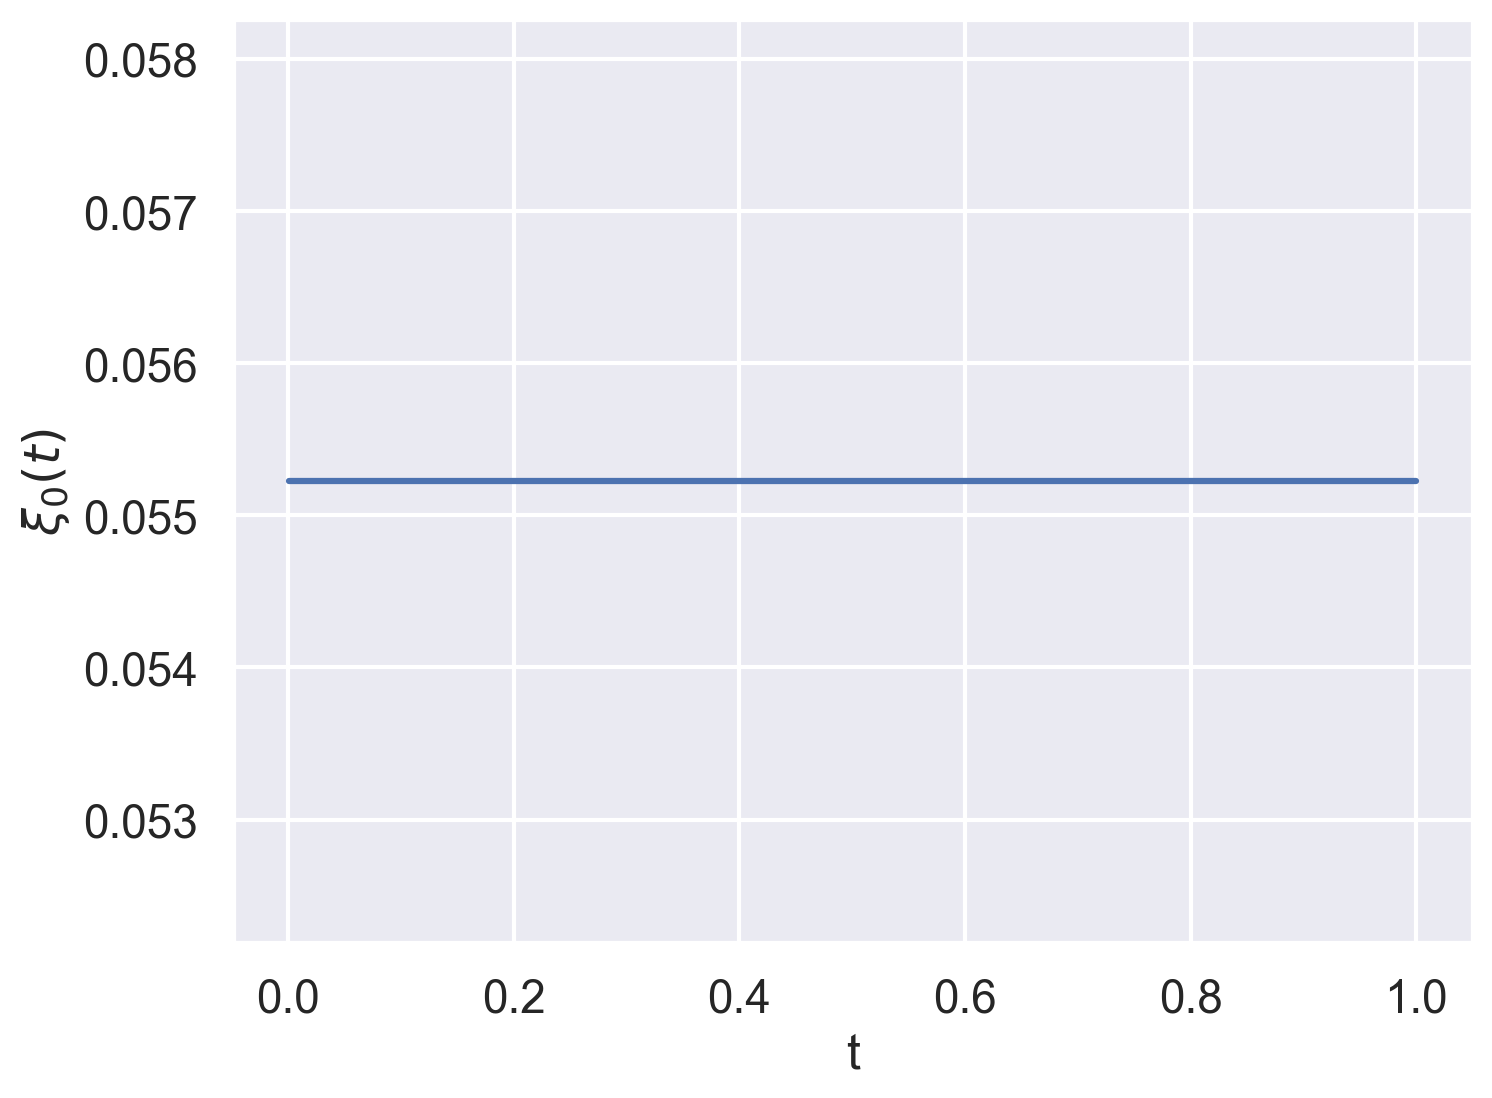

In [9]:
# plot xi0
ts = np.linspace(1e-3, 1.0, 101)
fig, ax = plt.subplots()
ax.plot(ts, onebergomi.xi0(ts))
ax.set_xlabel("t")
ax.set_ylabel(r"$\xi_0(t)$")
plt.show()

In [10]:
# log moneyness
ks = np.linspace(-0.1, 0.5, 11)

In [37]:
# VIX implied volatilities from Monte Carlo
n_quad = 80
impvol_vix = {
    month: onebergomi.implied_vol_vix(k=ks, T=T, n_quad=n_quad)
    for month, T in mats.items()
}

In [38]:
# VIX implied vol from weak approximation
impvol_vix_approx = {
    month: onebergomi.implied_vol_vix_approx(k=ks, T=T, order=3)
    for month, T in mats.items()
}

In [40]:
# VIX implied vol from expansion formula
impvol_vix_expansion = {
    month: onebergomi.implied_vol_vix_expansion(k=ks, T=T, order=1)
    for month, T in mats.items()
}

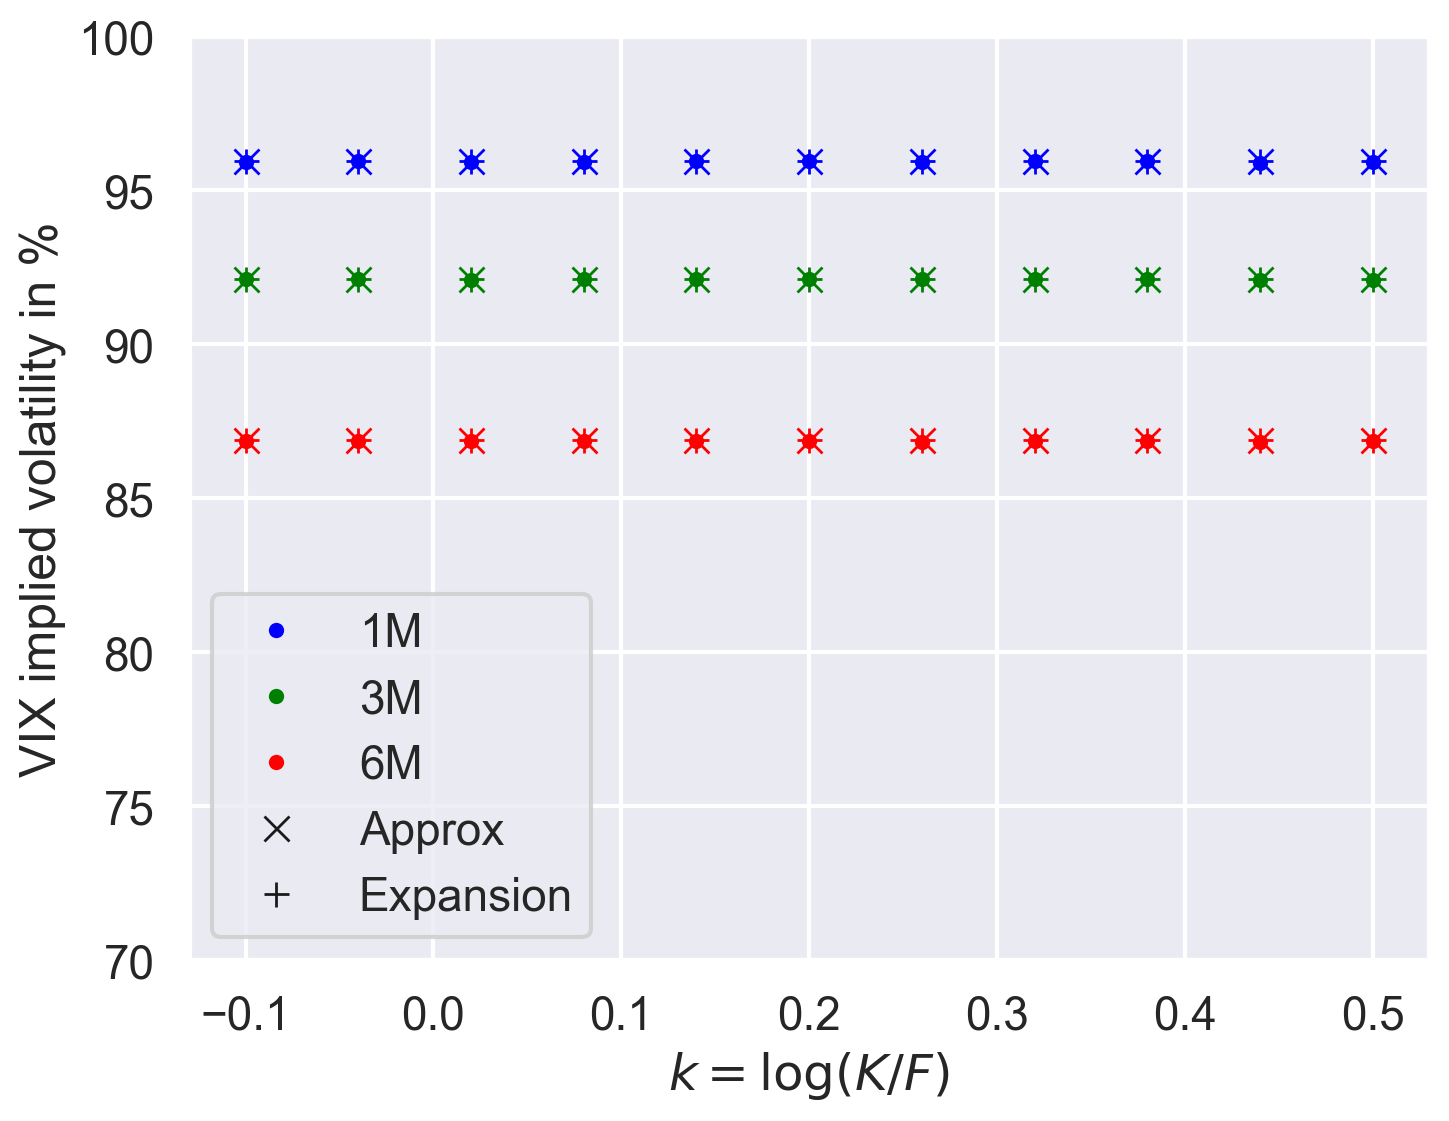

In [41]:
fig, ax = plt.subplots()
for i, month in enumerate(mats.keys()):
    ax.plot(ks, 100 * impvol_vix[month], ".", color=COLORS[i], label=f"{month}")
    ax.plot(ks, 100 * impvol_vix_approx[month], "x", color=COLORS[i])
    ax.plot(ks, 100 * impvol_vix_expansion[month], "+", color=COLORS[i])
ax.plot([], [], "kx", label="Approx")
ax.plot([], [], "k+", label="Expansion")
ax.set_xlabel(r"$k=\log(K/F)$")
ax.set_ylabel("VIX implied volatility in %")
ax.legend(loc="best")
ax.set_ylim(70, 100)
plt.show()

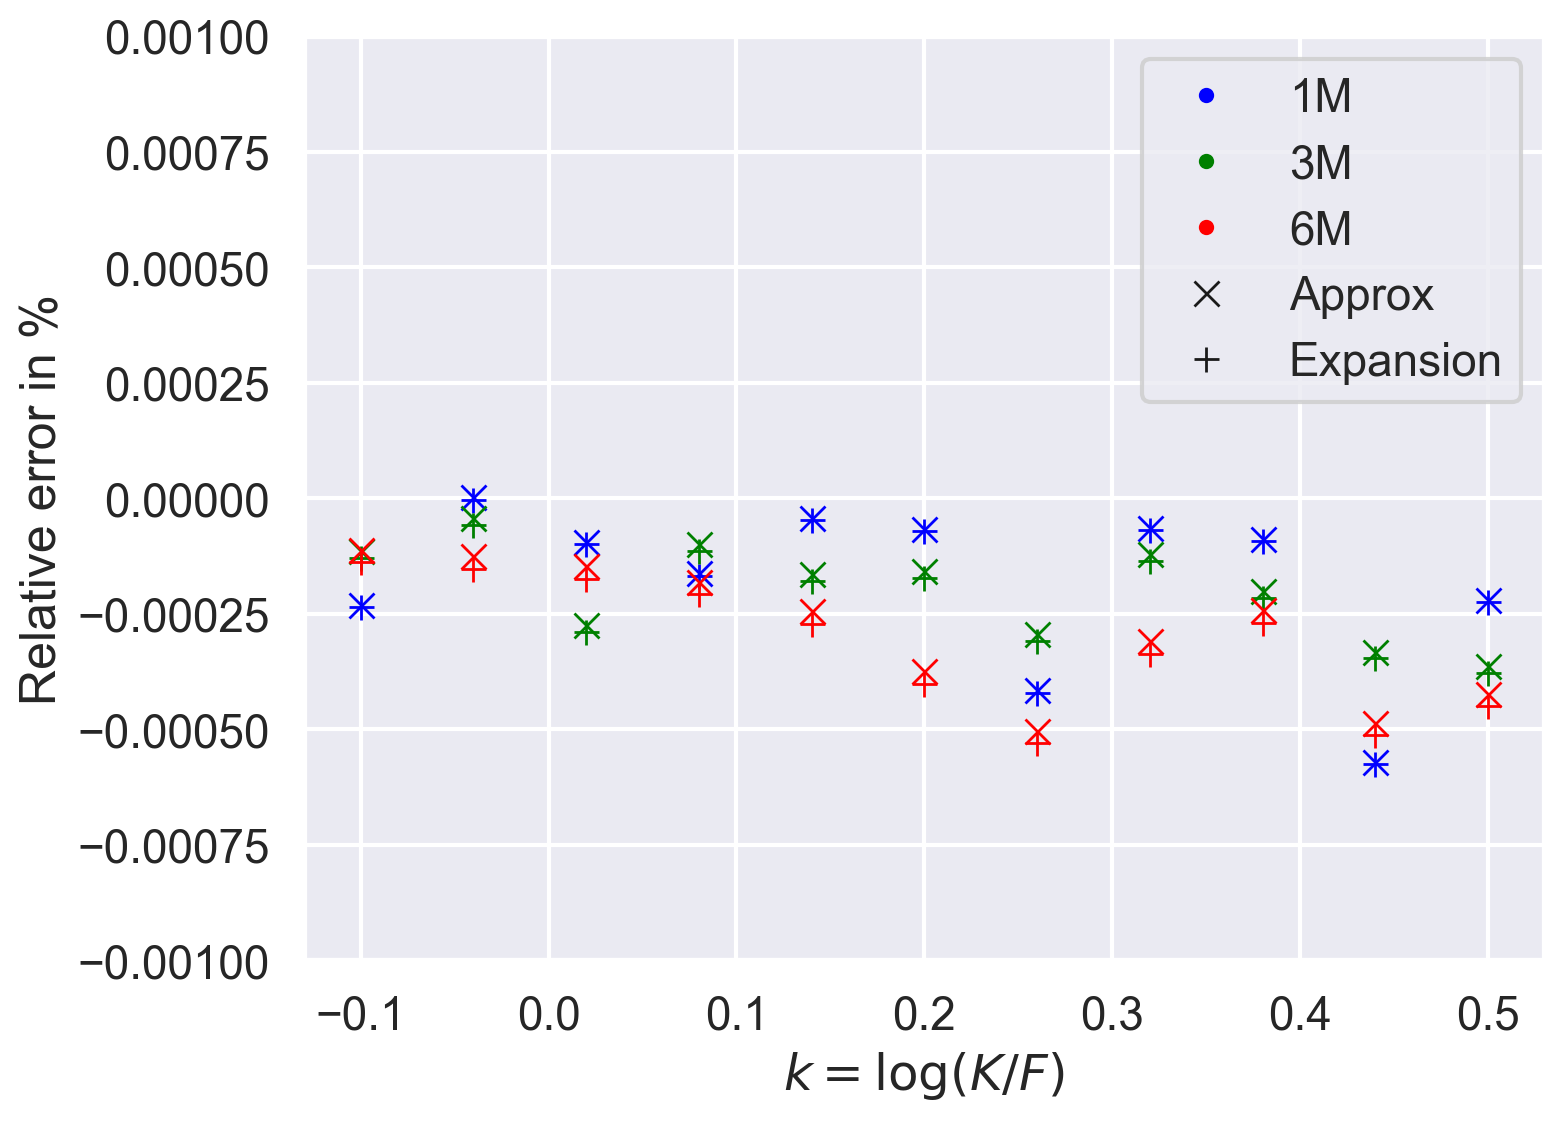

In [63]:
# relative errors
rel_error_approx = [
    relative_error(impvol_vix_approx[month], impvol_vix[month]) for month in mats
]
rel_error_expansion = [
    relative_error(impvol_vix_expansion[month], impvol_vix[month]) for month in mats
]

fig, ax = plt.subplots()
for i, month in enumerate(mats.keys()):
    ax.plot(ks, rel_error_approx[i], "x", color=COLORS[i])
    ax.plot(ks, rel_error_expansion[i], "+", color=COLORS[i])
    ax.plot([], [], ".", color=COLORS[i], label=f"{month}")
ax.plot([], [], "kx", label="Approx")
ax.plot([], [], "k+", label="Expansion")
ax.set_xlabel(r"$k=\log(K/F)$")
ax.set_ylabel("Relative error in %")
ax.legend(loc="best")
ax.set_ylim(-1e-3, 1e-3)
plt.show()